# ***__Credit-Card-Fraud-Detection__***
    ~ Author: Abdallah Salem

    

## Table Of Contents :

- Data Inspection
    - Overall Descriptive Statistics
<br><br>
- Feature Analysis
    - Target Feature
    - Numerical Features
    - Time-date Features
<br><br>
- Correlations
    - Numeric features with target
<br><br>
- PCA for Visualization
<br><br>
- Conclusions
    - Feature Engineering Insights


In [1]:
# import some libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
%matplotlib inline

# Disable warnings 
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('split/train.csv') # load data for investigation

# 1. Data Inspection

In [3]:
df.head()  # let's see our data frame

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,119191.0,2.052427,-0.133236,-1.740621,0.277935,0.337999,-0.826933,0.334629,-0.227039,0.267655,...,-0.006518,0.121300,0.037733,-0.356498,0.147822,0.569149,-0.103929,-0.091958,8.73,0
1,71750.0,1.220356,-0.159191,-0.444349,-0.094437,0.104457,-0.345790,0.170867,-0.094996,0.187572,...,-0.088775,-0.364654,-0.140851,-0.707308,0.415661,1.087767,-0.102532,-0.008335,59.95,0
2,151977.0,0.892824,-1.440698,-0.637940,3.912871,0.099291,2.433288,-0.308891,0.603227,-0.113826,...,0.484969,0.487304,-0.122694,-0.598803,-0.594563,0.062841,-0.033426,0.038254,460.65,0
3,55709.0,-3.146021,2.247634,0.901397,0.146162,-2.109360,-0.148312,-1.533191,2.073663,0.499394,...,0.050567,-0.037019,0.107000,0.392857,0.303597,0.379544,-0.148990,0.074965,4.78,0
4,66654.0,1.194996,-0.007495,0.301285,0.750199,-0.297494,-0.405836,0.060410,-0.150482,0.400860,...,-0.234931,-0.545566,-0.089418,-0.064036,0.527305,0.294221,-0.025980,0.015637,44.31,0


In [4]:
df.shape   # data diminsion 

(170884, 31)

### Observatoins
- We have 30 features and 170884 record
- Time & Amount Features only known

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170884 entries, 0 to 170883
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    170884 non-null  float64
 1   V1      170884 non-null  float64
 2   V2      170884 non-null  float64
 3   V3      170884 non-null  float64
 4   V4      170884 non-null  float64
 5   V5      170884 non-null  float64
 6   V6      170884 non-null  float64
 7   V7      170884 non-null  float64
 8   V8      170884 non-null  float64
 9   V9      170884 non-null  float64
 10  V10     170884 non-null  float64
 11  V11     170884 non-null  float64
 12  V12     170884 non-null  float64
 13  V13     170884 non-null  float64
 14  V14     170884 non-null  float64
 15  V15     170884 non-null  float64
 16  V16     170884 non-null  float64
 17  V17     170884 non-null  float64
 18  V18     170884 non-null  float64
 19  V19     170884 non-null  float64
 20  V20     170884 non-null  float64
 21  V21     17

### Observatoins
- No null values
- All featuers are of type float

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,...,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000,170884.000000
mean,94966.107886,-0.001070,-0.000904,-0.002722,-0.002603,0.000151,0.000779,-0.000811,-0.002327,-0.000622,...,0.000957,0.000056,0.000475,-0.000894,-0.000593,-0.000738,0.000404,0.000422,88.511723,0.001785
std,47464.723773,1.958944,1.650481,1.521820,1.416490,1.394123,1.338331,1.260122,1.208709,1.098393,...,0.743974,0.726681,0.620647,0.605148,0.521128,0.481720,0.404540,0.314973,256.737144,0.042210
min,0.000000,-46.855047,-63.344698,-48.325589,-5.683171,-113.743307,-23.496714,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-36.666000,-2.836627,-7.081325,-2.604551,-9.895244,-15.430084,0.000000,0.000000
25%,54348.000000,-0.922071,-0.599127,-0.896376,-0.848978,-0.691840,-0.768986,-0.554440,-0.209596,-0.642036,...,-0.228068,-0.542831,-0.161063,-0.354552,-0.318057,-0.327631,-0.070719,-0.053019,5.637500,0.000000
50%,84923.500000,0.016603,0.065839,0.177007,-0.020895,-0.054185,-0.274228,0.040417,0.021461,-0.051777,...,-0.029547,0.006488,-0.010688,0.040433,0.016916,-0.051262,0.001520,0.011216,22.020000,0.000000
75%,139404.000000,1.316250,0.802518,1.028302,0.738812,0.612154,0.400359,0.569221,0.326026,0.595095,...,0.186681,0.528971,0.147814,0.437888,0.350188,0.240718,0.091713,0.078480,77.650000,0.000000
max,172792.000000,2.451888,22.057729,4.226108,16.875344,34.099309,73.301626,120.589494,18.282168,10.392889,...,27.202839,10.503090,22.528412,4.584549,6.070850,3.517346,31.612198,16.129609,25691.160000,1.000000


In [7]:
df.skew()

Time      -0.039429
V1        -3.219164
V2        -4.595180
V3        -2.264603
V4         0.682350
V5        -3.832642
V6         2.234061
V7         4.421435
V8        -9.103418
V9         0.527373
V10        1.003994
V11        0.347855
V12       -2.301048
V13        0.072673
V14       -1.974437
V15       -0.299761
V16       -1.105041
V17       -3.940282
V18       -0.262413
V19        0.099712
V20       -2.021569
V21        3.463795
V22       -0.208784
V23       -4.767693
V24       -0.541481
V25       -0.396849
V26        0.566494
V27        0.514650
V28        5.064013
Amount    19.991968
Class     23.606927
dtype: float64

### Observations
- Time Feature may be in **seconds**
- All features has good distribution except **Amount feature** is skewed
- Time and Amount featuers have the **high variances**

# 2. Feature Analysis

## 2.1. Target Feature

In [8]:
df['Class'].value_counts()

Class
0    170579
1       305
Name: count, dtype: int64

### Observations
- **Geniune transactions** are the Majority Class
- **Fraud transactions** are the Minority Class
### Thougts
- Let's visualize the distribution of classes

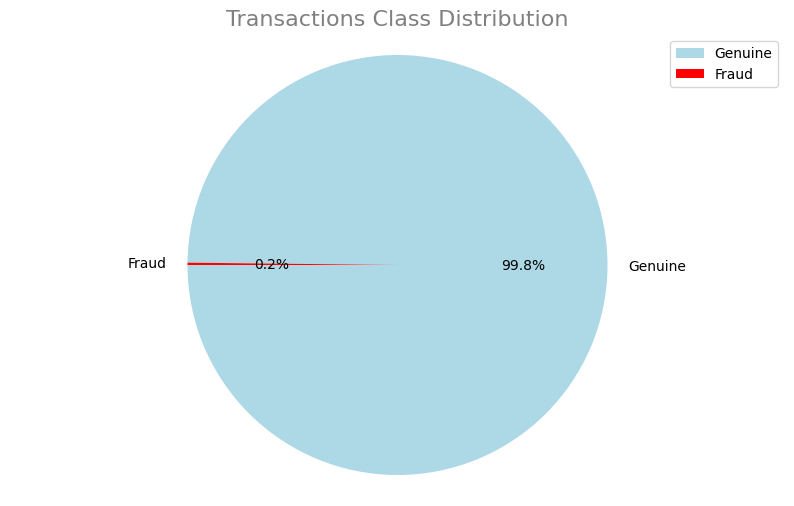

In [9]:
# Visualize proportions of fraud class and genuine class

Genuine = len(df[df['Class']==0])   # number of genuines
Fraud = len(df[df['Class']==1])     # number of frauds
plt.figure(figsize=(10,6))
plt.pie([Genuine, Fraud], labels=['Genuine', 'Fraud'],autopct='%1.1f%%',startangle=180, colors=['lightblue', 'red'])
plt.title('Transactions Class Distribution', fontsize=16, color='grey')
plt.axis('equal')
plt.legend()
plt.show()

### Observations
-  Geniune transactions are **99.8%** of dataset (Majority Class)
-  Fraud transactions are **< 0.2%** of dataset (Minority Class)
### Thoughts
- We have **Imbalanced dataset** which requires some techniques to tackle this problem and help our model to generalize

## 2.2. Amount Feature

In [10]:
df['Amount'].describe()

count    170884.000000
mean         88.511723
std         256.737144
min           0.000000
25%           5.637500
50%          22.020000
75%          77.650000
max       25691.160000
Name: Amount, dtype: float64

In [11]:
# let's see mean of amount according to class type
df[df['Class']==1]['Amount'].mean(), df[df['Class']==0]['Amount'].mean()

(np.float64(126.74773770491802), np.float64(88.44335592306206))

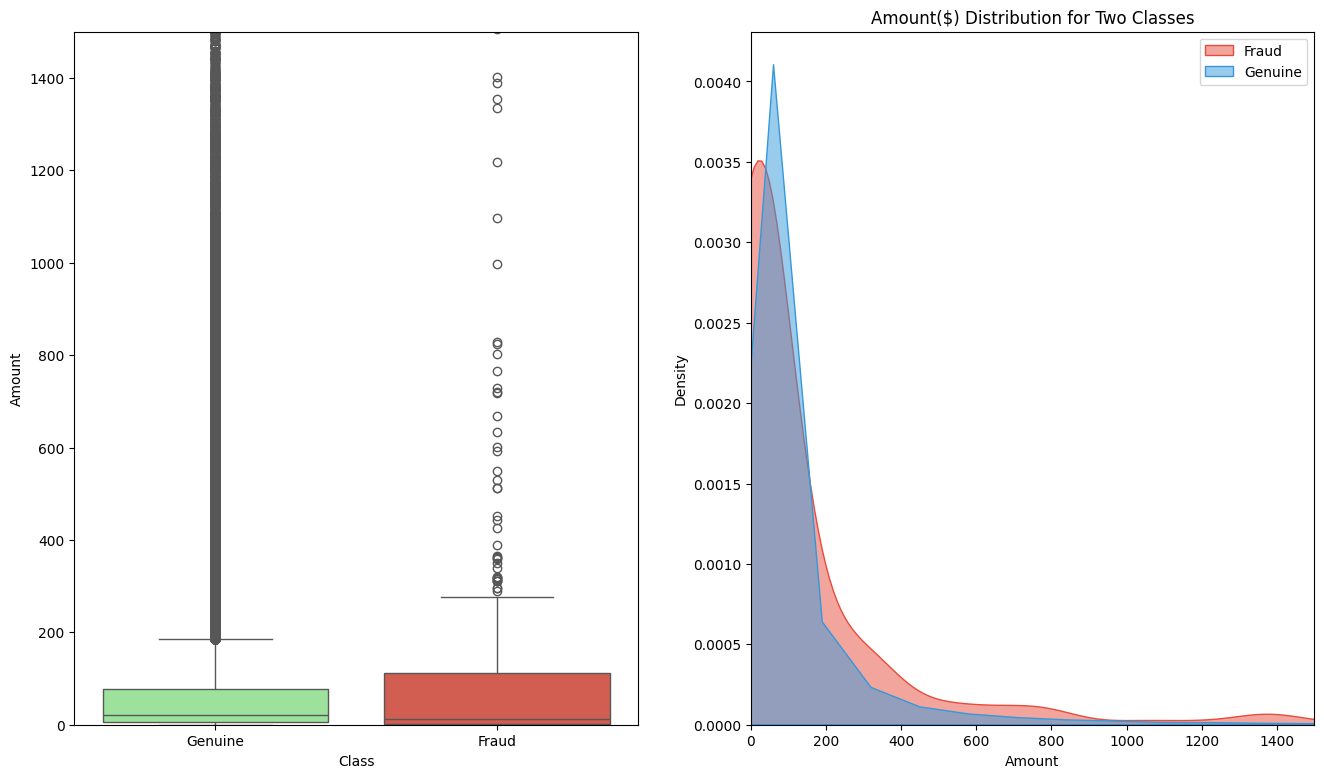

In [12]:
# Visualize Amount distribution for two classes (boxplot - density)

fig, axes = plt.subplots(nrows=1,ncols=2,figsize=(16,9))    # two plots


sns.boxplot(data=df, x='Class', y='Amount', palette=['lightgreen', '#e74c3c'],ax=axes[0])
axes[0].set_xticks([0,1],['Genuine', 'Fraud'])
axes[0].set_ylim(0,1500)

sns.kdeplot(df[df['Class']==1]['Amount'],fill=True,alpha=0.5, label='Fraud', color='#e74c3c', ax=axes[1])
sns.kdeplot(df[df['Class']==0]['Amount'], fill=True, alpha=0.5, label='Genuine', color='#3498db', ax=axes[1])
axes[1].set_xlim(0,1500)
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Density')


plt.title('Amount($) Distribution for Two Classes')
plt.legend()
plt.show()

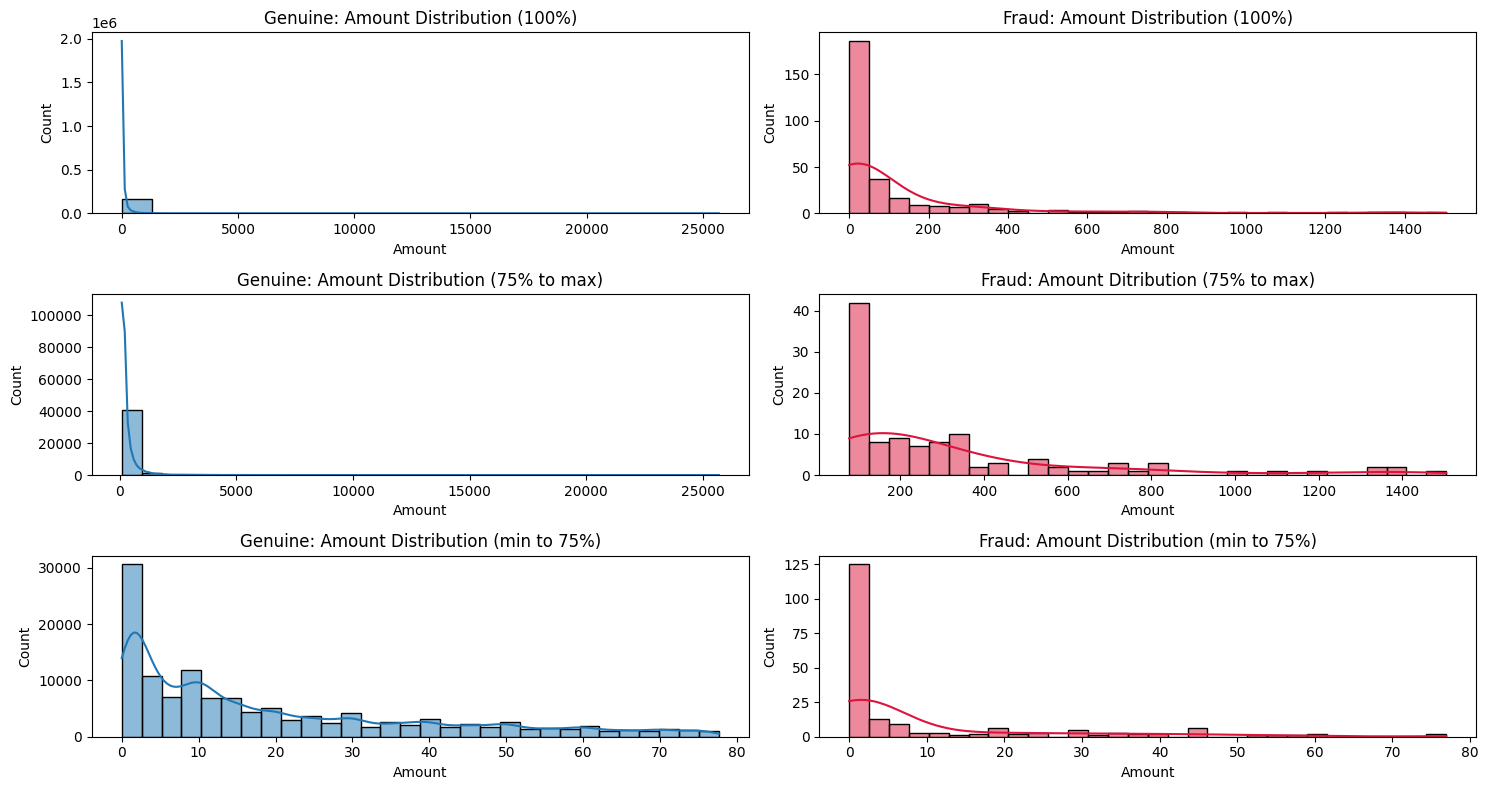

In [13]:
# Visualize Amount distribution with different precentiles (histogram)

fraud = df[df['Class']==1]['Amount']
genuine = df[df['Class']==0]['Amount']
most_genuine = df[(df['Class']==0) & (df['Amount'] >= df['Amount'].quantile(0.75))]['Amount']
most_fraud = df[(df['Class']==1) & (df['Amount'] >= df['Amount'].quantile(0.75))]['Amount']
min_genuine = df[(df['Class']==0) & (df['Amount'] <= df['Amount'].quantile(0.75))]['Amount']
min_fraude = df[(df['Class']==1) & (df['Amount'] <= df['Amount'].quantile(0.75))]['Amount']


fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15,8))

# 100 precentile of dataset
sns.histplot(genuine, bins=20, kde=True, ax=axes[0,0])
axes[0,0].set_title('Genuine: Amount Distribution (100%)')
sns.histplot(fraud, bins=30, kde=True,ax=axes[0,1], color='crimson')
axes[0,1].set_title('Fraud: Amount Distribution (100%)')

# Above 75% percentile of dataset
sns.histplot(most_genuine,bins=30,kde=True,ax=axes[1,0])
axes[1,0].set_title('Genuine: Amount Distribution (75% to max)')
sns.histplot(most_fraud,bins=30,kde=True,ax=axes[1,1],color='crimson')
axes[1,1].set_title('Fraud: Amount Ditribution (75% to max)')

# Below 75% percentile of dataset
sns.histplot(min_genuine,bins=30,kde=True,ax=axes[2,0])
axes[2,0].set_title('Genuine: Amount Distribution (min to 75%)')
sns.histplot(min_fraude,bins=30,kde=True,ax=axes[2,1],color='crimson')
axes[2,1].set_title('Fraud: Amount Distribution (min to 75%)')


plt.tight_layout()
plt.show()

### Observation
- Fraud Transactions' Amount is concentrated in between **0 dollar to 1500 dollar**
- Genuine transactions' Amount have wider range than Frauds'

## 2.3. Time Feature

In [14]:
df['Time'].describe()

count    170884.000000
mean      94966.107886
std       47464.723773
min           0.000000
25%       54348.000000
50%       84923.500000
75%      139404.000000
max      172792.000000
Name: Time, dtype: float64

### Observation
- The most likely thing is these values are in seconds but not for one day may be for two days (48 hours)
- So I will extract time features that will suit this problem

In [15]:
# Extracting some time features which will help for exploring

df['hour'] = ((df['Time']//3600) % 24).astype(int)      # hours
df['minute'] = ((df['Time']//60) % (24*60)).astype(int) # minutes
df['second'] = ((df['Time']) % (24*60*60)).astype(int)  # seconds

# day periods
bins = [0, 5, 12, 18, 24]
labels = ['Night\n(0-6)', 'Morning\n(6-12)', 'Afternoon\n(12-18)', 'Evening\n(18-24)']
# day period column
df['day_period'] = pd.cut(df['hour'], bins=bins, labels=labels, include_lowest=True, right=False)

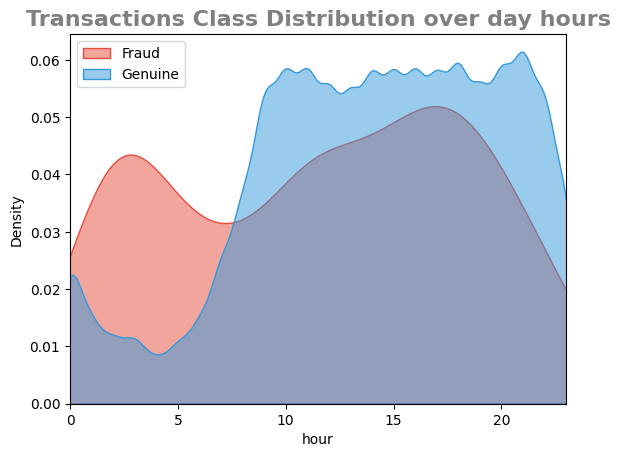

In [16]:
# Visualize distribution of two classes over day hours

sns.kdeplot(df[df['Class']==1]['hour'],fill=True,alpha=0.5, label='Fraud', color='#e74c3c')
sns.kdeplot(df[df['Class']==0]['hour'], fill=True, alpha=0.5, label='Genuine', color='#3498db')
plt.title('Transactions Class Distribution over day hours', fontsize=16, color='grey', weight='bold')
plt.xlim(0,23)     # 24 hours
plt.xlabel('hour')
plt.ylabel('Density')
plt.legend()
plt.show()

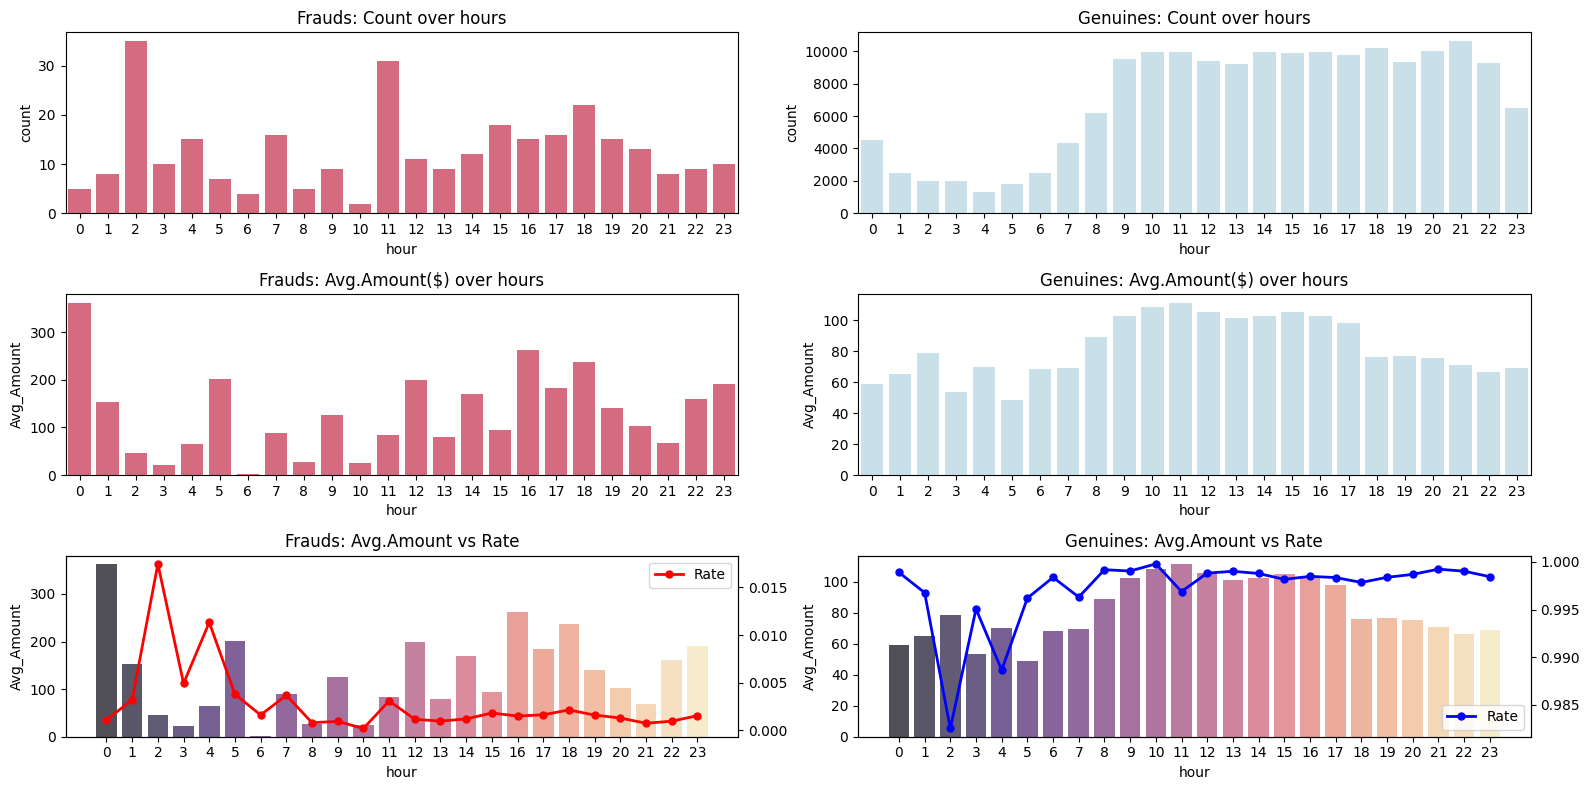

In [17]:
# Visualize Amount (Average, Rate, count) over day hours for our classes 

# Calculate both classes
fraud_stats = df[df['Class']==1].groupby(['hour']).agg({
    'Amount': ['mean', 'count']
}).reset_index()
fraud_stats.columns = ['hour', 'Avg_Amount', 'count']

genuine_stats = df[df['Class']==0].groupby(['hour']).agg({
    'Amount': ['mean', 'count']
}).reset_index()
genuine_stats.columns = ['hour', 'Avg_Amount', 'count']

# transaction rate column
fraud_stats['fraud_rate'] = fraud_stats['count'] / (fraud_stats['count'] + genuine_stats['count'])
genuine_stats['genuine_rate'] = genuine_stats['count'] / (fraud_stats['count'] + genuine_stats['count'])


fig, axes = plt.subplots(nrows=3,ncols=2, figsize=(16,8))

# count over day hours
sns.barplot(data=fraud_stats, x='hour', y='count', color='crimson',alpha=0.7, ax=axes[0,0])
axes[0,0].set_title('Frauds: Count over hours')

sns.barplot(data=genuine_stats, x='hour', y='count', color='lightblue', alpha=0.7, ax=axes[0,1])
axes[0,1].set_title('Genuines: Count over hours')

# Avg. Amount over day hours
sns.barplot(data=fraud_stats,x='hour', y='Avg_Amount', color='crimson',alpha=0.7, ax=axes[1,0])
axes[1,0].set_title('Frauds: Avg.Amount($) over hours')

sns.barplot(data=genuine_stats, x='hour', y='Avg_Amount', color='lightblue',alpha=0.7, ax=axes[1,1])
axes[1,1].set_title('Genuines: Avg.Amount($) over hours')

# Avg. Amount vs Rate over day hours
fraud = axes[2,0]
fraud_count = fraud.twinx()
sns.barplot(data=fraud_stats, x='hour', y='Avg_Amount', palette='magma', ax=fraud, alpha=0.7)
fraud_count.plot(fraud_stats['hour'], fraud_stats['fraud_rate'], color='red', marker='o', linewidth=2, markersize=5, label='Rate')
fraud.set_title('Frauds: Avg.Amount vs Rate')
fraud_count.legend(loc='best')


genuine = axes[2,1]
genuine_count = axes[2,1].twinx()
sns.barplot(data=genuine_stats, x='hour', y='Avg_Amount', palette='magma', ax=genuine, alpha=0.7)
genuine_count.plot(genuine_stats['hour'], genuine_stats['genuine_rate'], color='blue', marker='o', linewidth=2, markersize=5, label='Rate')
genuine.set_title('Genuines: Avg.Amount vs Rate')
genuine_count.legend(loc='best')


plt.tight_layout()
plt.show()

### Observation
- **All Fraud Transactions count** are under 30 times through a day while **all Genuine Transactions count** above 1000 times
- **Highest Fraud Rates** are from **2am to 4am**
- **Fraud Transactions Avg. Amount** through hours (0,1,5,9,12,14,16,17,18,19,20,22,23) are higher than Genuines

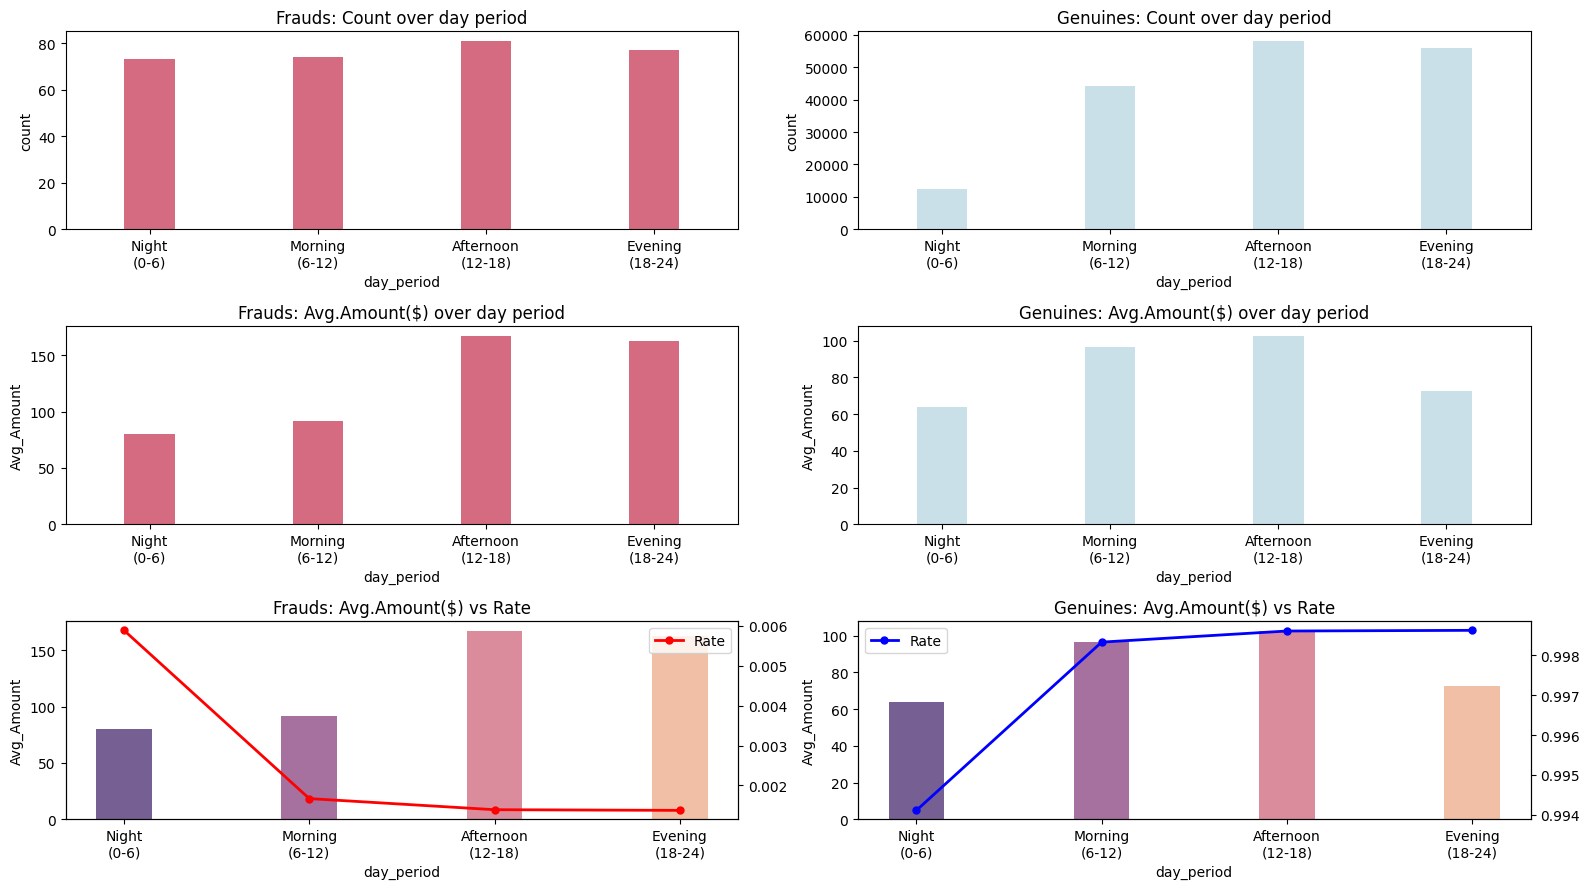

In [18]:
# Calculate both classes
fraud_stats = df[df['Class']==1].groupby(['day_period']).agg({
    'Amount': ['mean', 'count']
}).reset_index()
fraud_stats.columns = ['day_period', 'Avg_Amount', 'count']

genuine_stats = df[df['Class']==0].groupby(['day_period']).agg({
    'Amount': ['mean', 'count']
}).reset_index()
genuine_stats.columns = ['day_period', 'Avg_Amount', 'count']

# transaction rate column
fraud_stats['fraud_rate'] = fraud_stats['count'] / (fraud_stats['count'] + genuine_stats['count'])
genuine_stats['genuine_rate'] = genuine_stats['count'] / (fraud_stats['count'] + genuine_stats['count'])



fig, axes = plt.subplots(nrows=3,ncols=2, figsize=(16,9))

# count over day hours
sns.barplot(data=fraud_stats, x='day_period', y='count', color='crimson',alpha=0.7, ax=axes[0,0],width=0.3)
axes[0,0].set_title('Frauds: Count over day period')

sns.barplot(data=genuine_stats, x='day_period', y='count', color='lightblue', alpha=0.7, ax=axes[0,1], width=0.3)
axes[0,1].set_title('Genuines: Count over day period')

# Avg. Amount over day hours
sns.barplot(data=fraud_stats,x='day_period', y='Avg_Amount', color='crimson',alpha=0.7, ax=axes[1,0], width=0.3)
axes[1,0].set_title('Frauds: Avg.Amount($) over day period')

sns.barplot(data=genuine_stats, x='day_period', y='Avg_Amount', color='lightblue',alpha=0.7, ax=axes[1,1], width=0.3)
axes[1,1].set_title('Genuines: Avg.Amount($) over day period')

# Avg. Amount vs Rate over day hours
fraud = axes[2,0]
fraud_count = fraud.twinx()
sns.barplot(data=fraud_stats, x='day_period', y='Avg_Amount', palette='magma', ax=fraud, alpha=0.7, width=0.3)
fraud_count.plot(fraud_stats['day_period'], fraud_stats['fraud_rate'], color='red', marker='o', linewidth=2, markersize=5, label='Rate')
fraud.set_title('Frauds: Avg.Amount($) vs Rate')
fraud_count.legend(loc='best')


genuine = axes[2,1]
genuine_count = axes[2,1].twinx()
sns.barplot(data=genuine_stats, x='day_period', y='Avg_Amount', palette='magma', ax=genuine, alpha=0.7,width=0.3)
genuine_count.plot(genuine_stats['day_period'], genuine_stats['genuine_rate'], color='blue', marker='o', linewidth=2, markersize=5, label='Rate')
genuine.set_title('Genuines: Avg.Amount($) vs Rate')
genuine_count.legend(loc='best')



plt.tight_layout()
plt.show()

### Observation
- Fraud Transaction Count are **nearly equal** through time period
- Genuine Transaction Count in **Evening are very low** which is reasonable
- Fraud Transaction Avg Amount is **very high in Afternoon and Evening**
- Genuine Transaction Avg Amount in **Night is the lowest**
- Fraud Transactions **Rate** in Night is the highest while **Avg Amount** is the lowest
- Genuine Transactions: **Rate** in Night is the lowest and **Avg Amount** also

## 2.4. Anonymous Features

In [19]:
# Anonymous Features
anonymous_features = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28','Class']

plt.style.use('dark_background')  # Dark mode syle

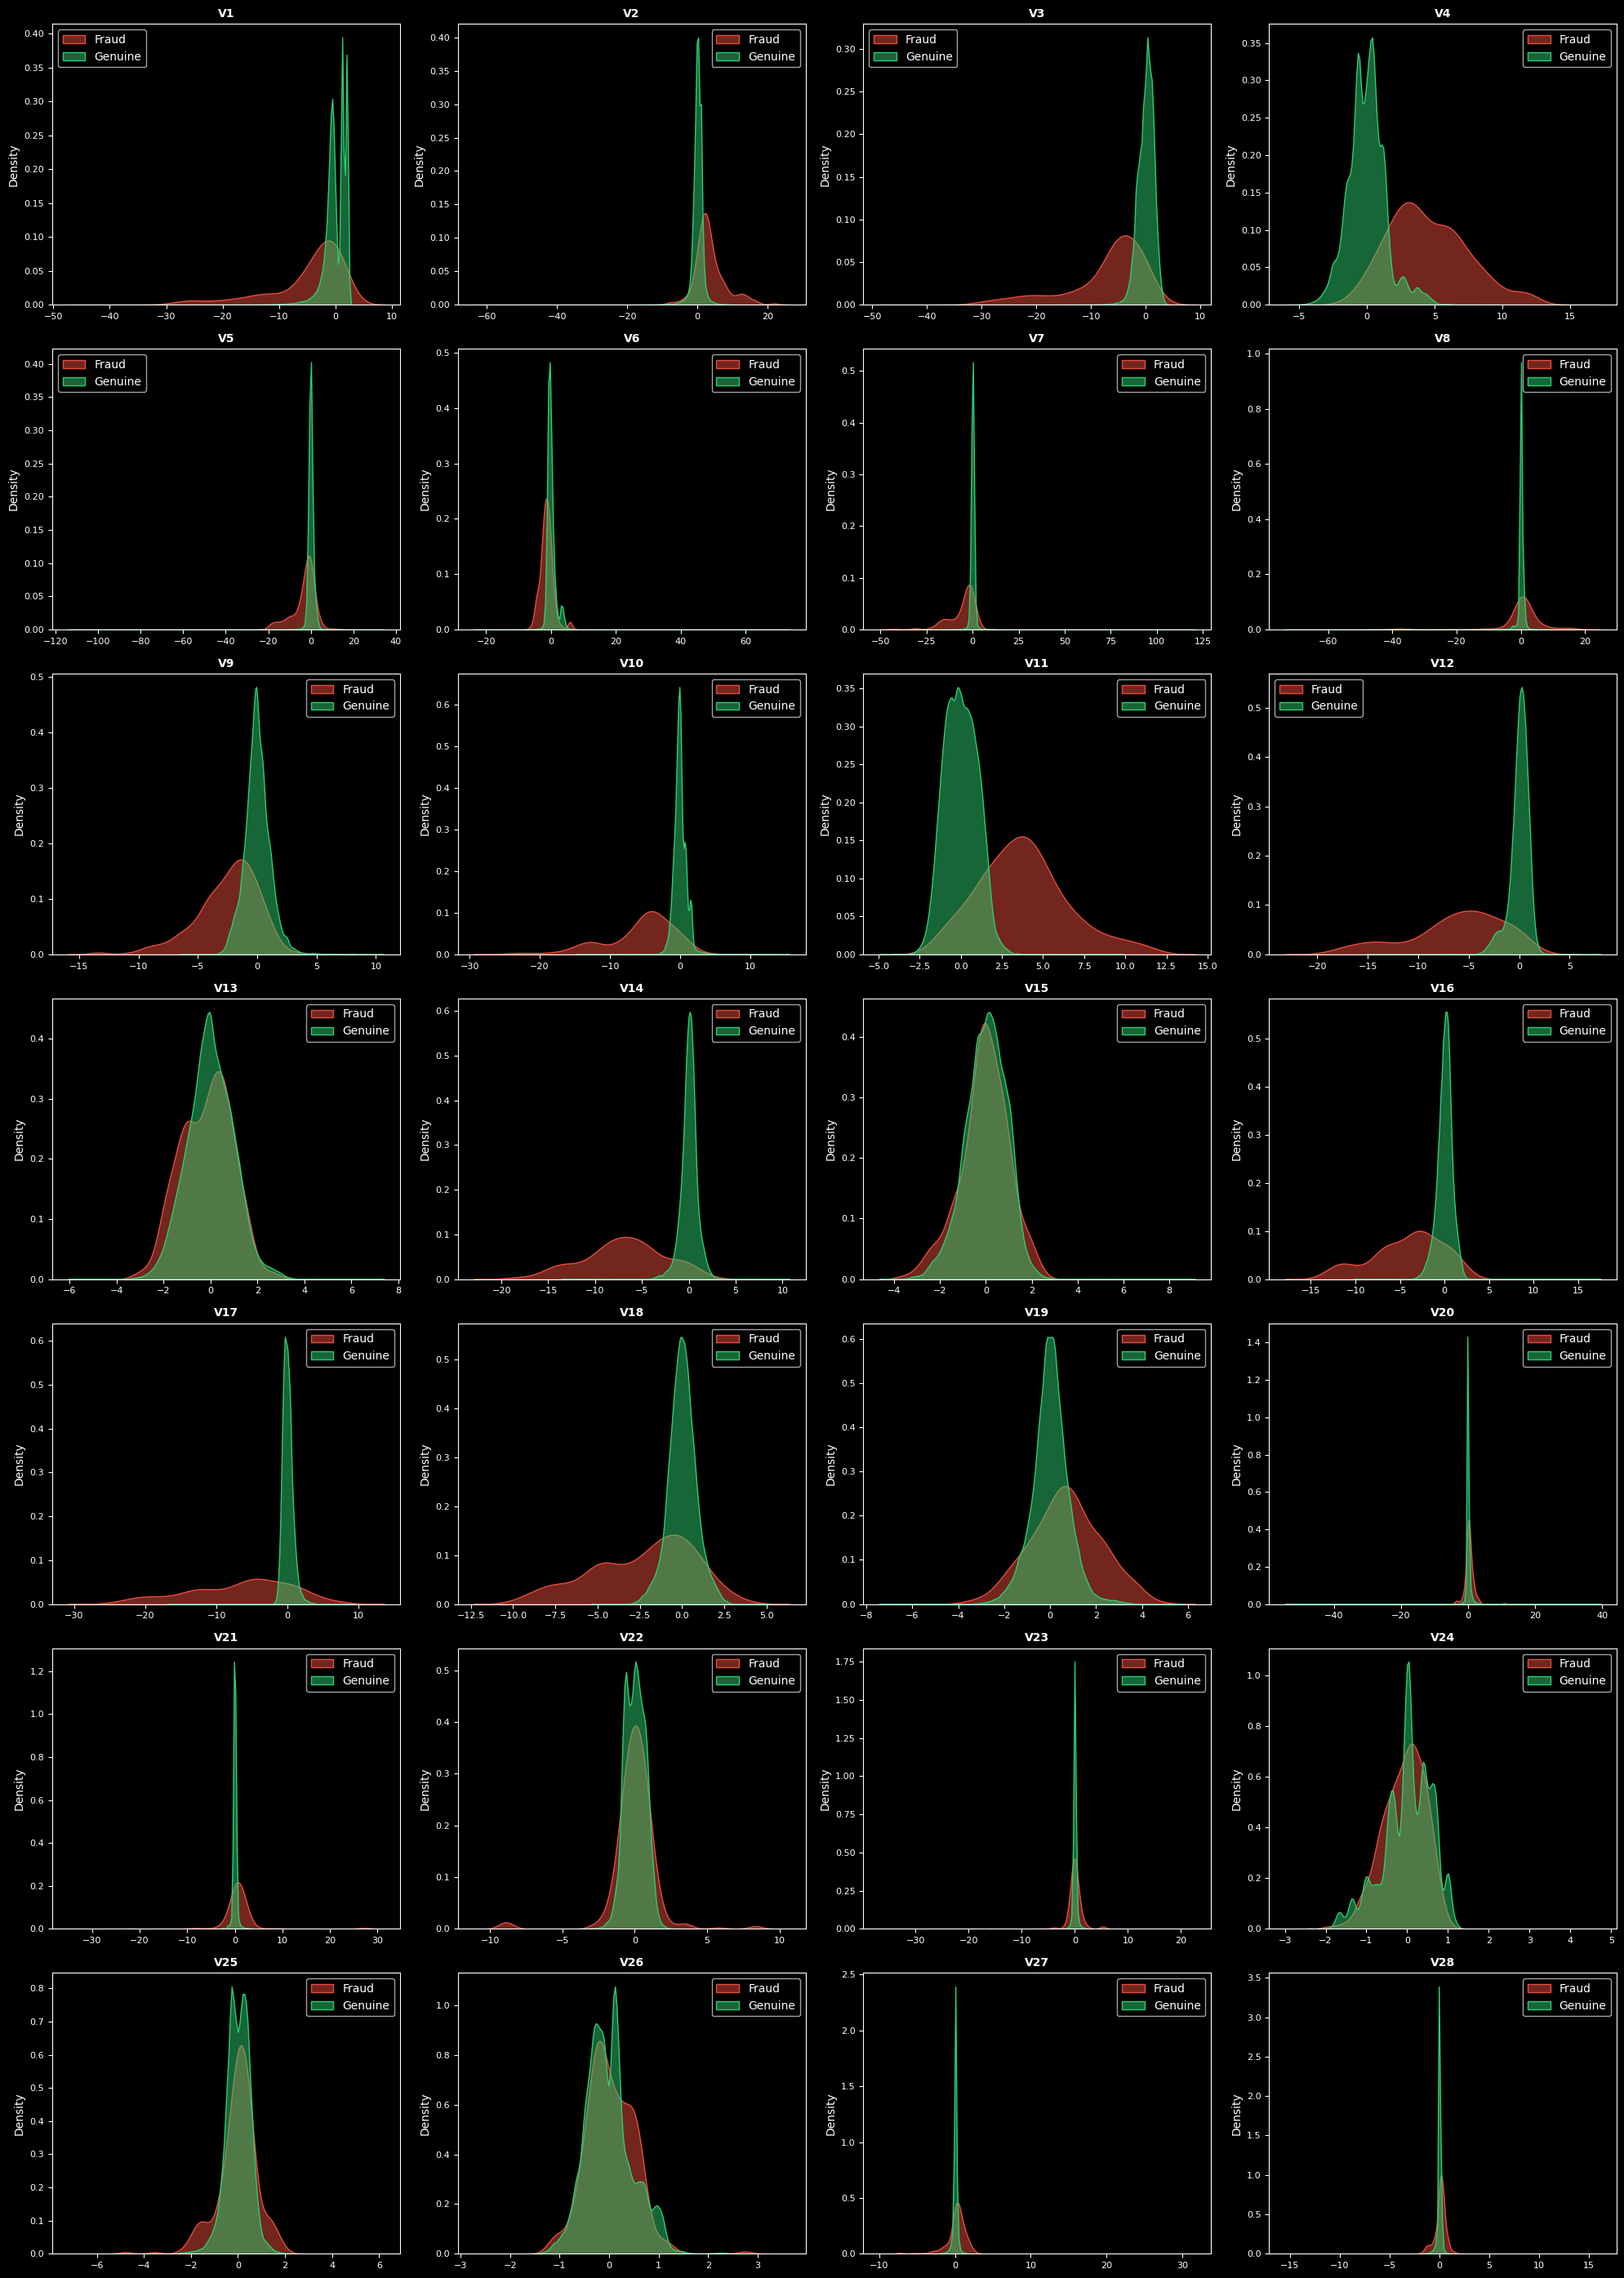

In [20]:
# Visualize different distributions of two classes among all anonymous features
fraud_df = df[df['Class']==1][anonymous_features]
genuine_df = df[df['Class']==0][anonymous_features]

fig, axes = plt.subplots(nrows=7, ncols=4, figsize=(20,28))

# loop over features and visualize
for row in range(7):
    for col in range(4):
        sns.kdeplot(fraud_df[anonymous_features[(row*4)+col]],fill=True,alpha=0.5, label='Fraud', color='#e74c3c',ax=axes[row,col])
        sns.kdeplot(genuine_df[anonymous_features[(row*4)+col]],fill=True,alpha=0.5, label='Genuine', color='#2ecc71',ax=axes[row,col])
        axes[row,col].set_title(f'{anonymous_features[(row*4)+col]}', fontsize=10,weight='bold')
        axes[row,col].set_xlabel('')
        axes[row,col].tick_params(axis='both', labelsize=8)
        axes[row,col].set_ylabel('Density')
        axes[row,col].legend()


plt.tight_layout()
plt.show()

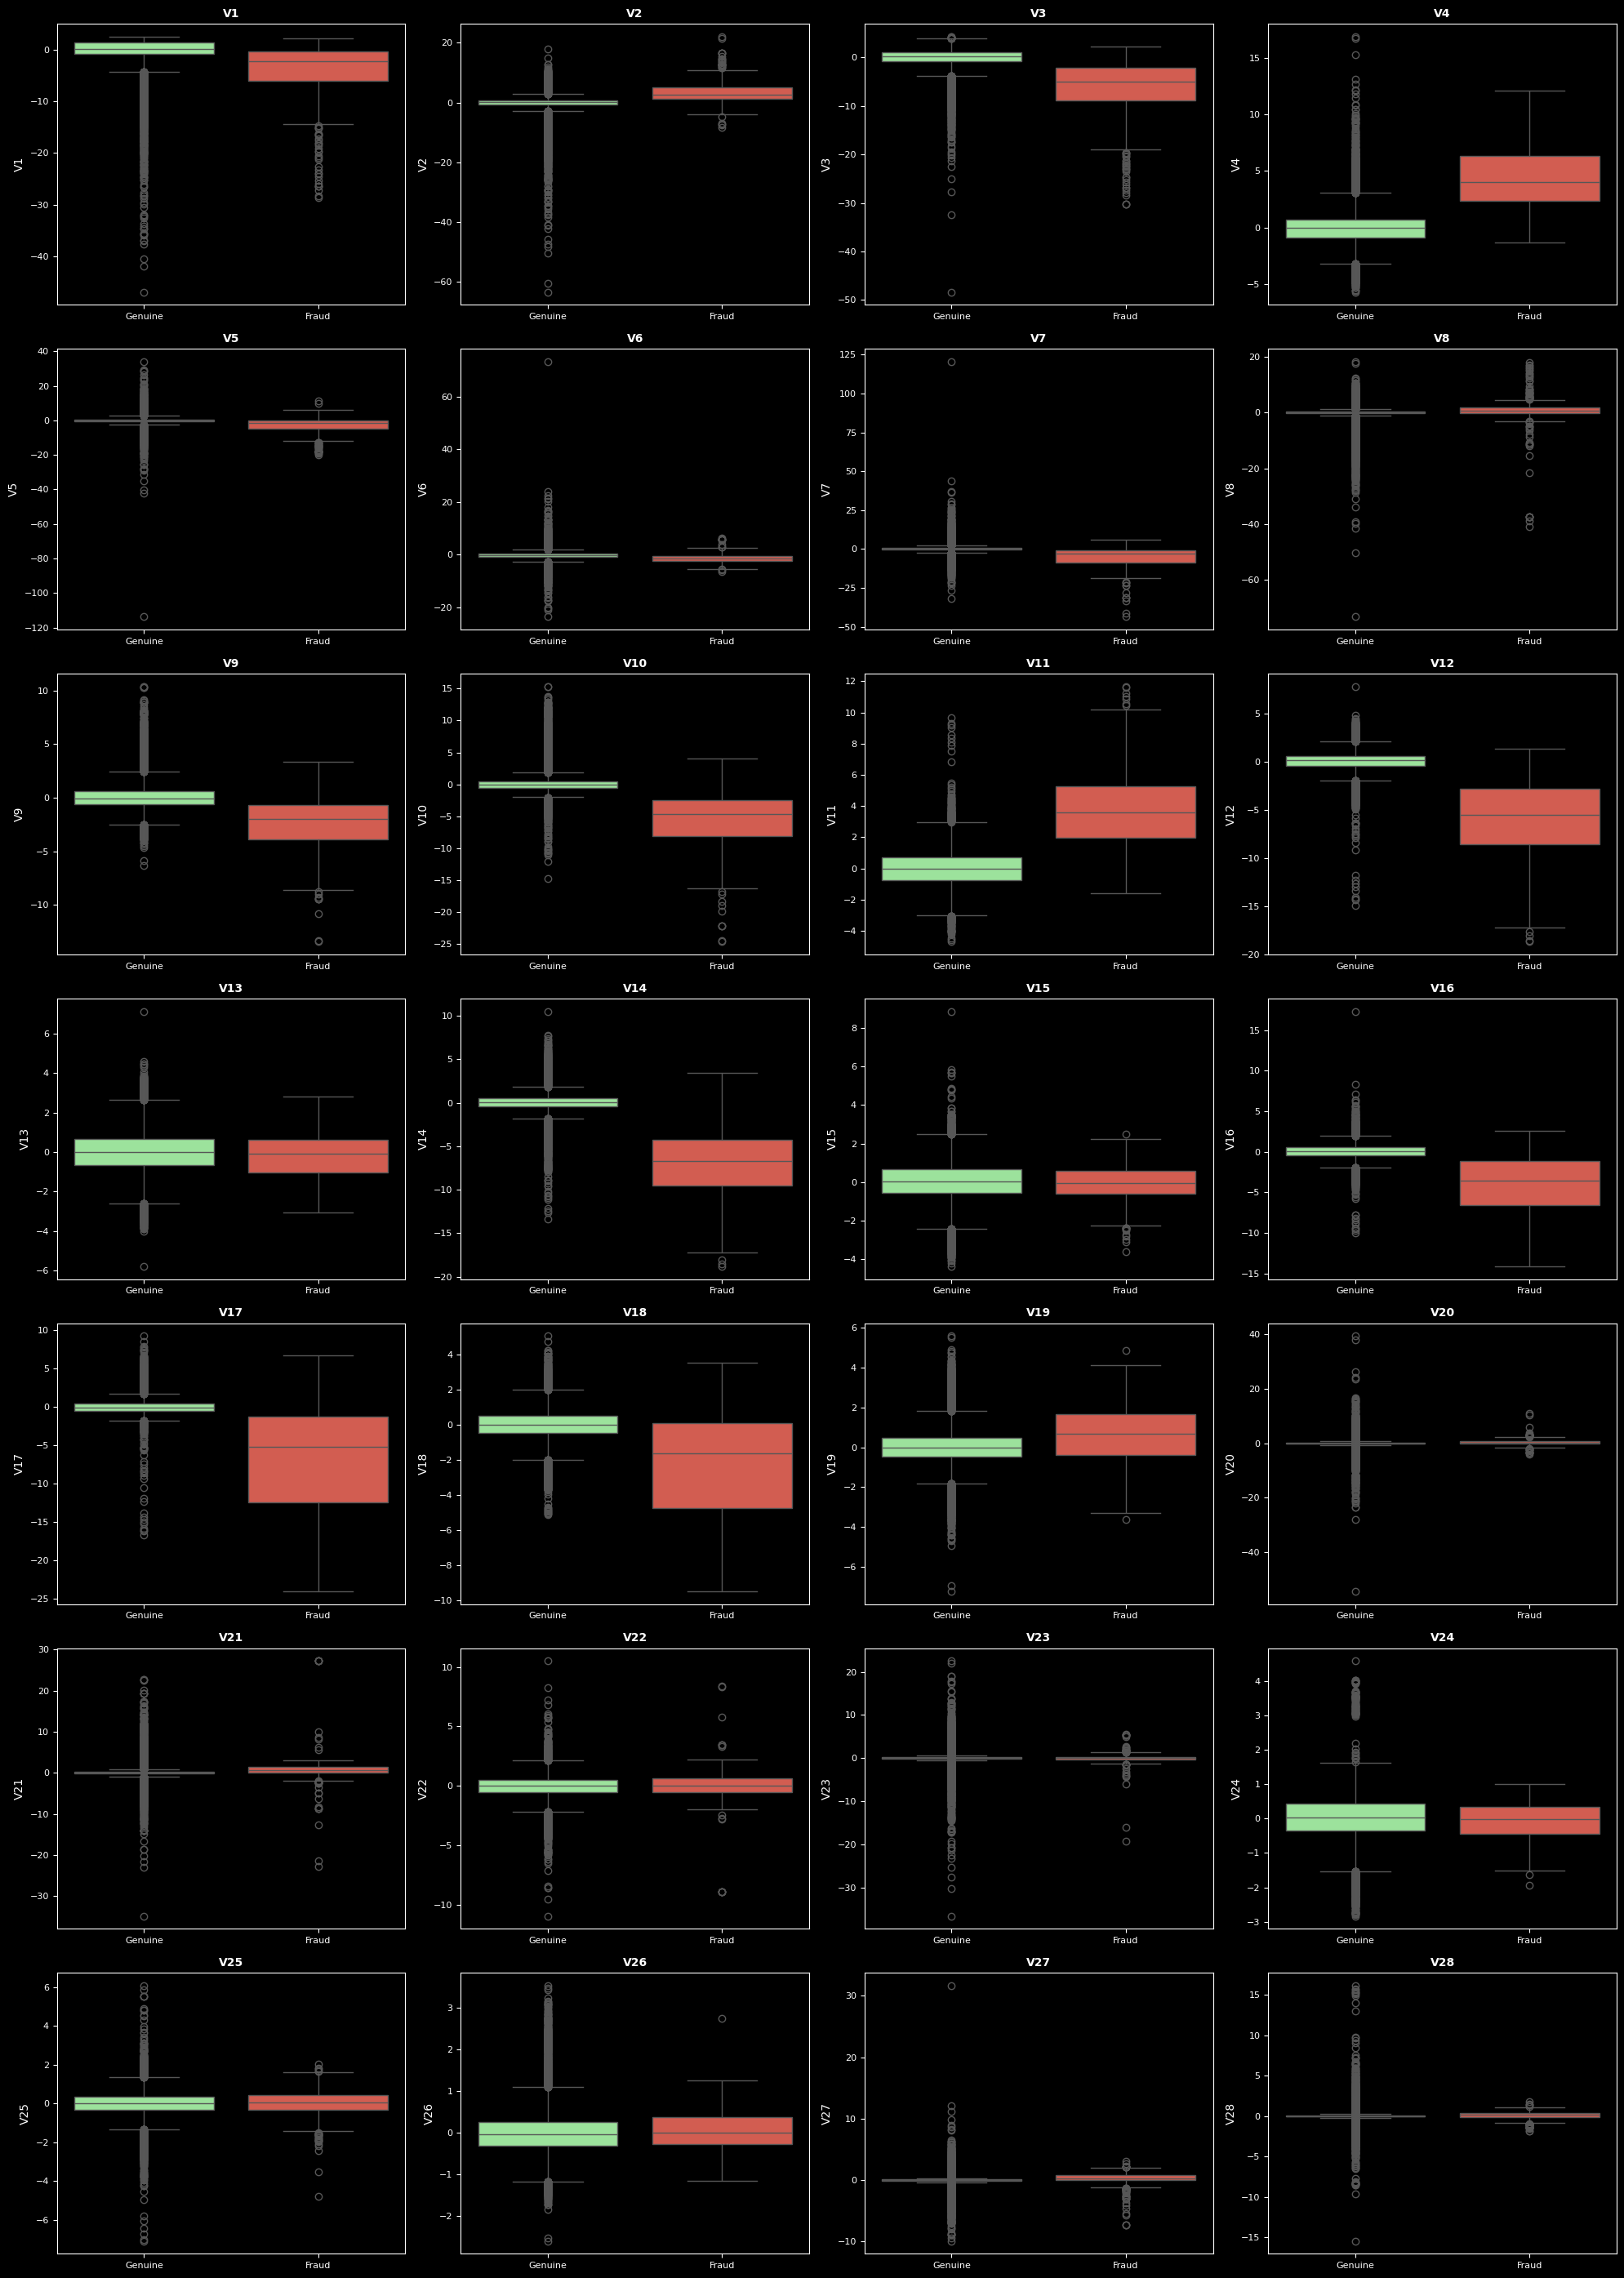

In [21]:
# Visualize different distributions of two classes among all anonymous features
fig, axes = plt.subplots(nrows=7, ncols=4, figsize=(20,28))

for row in range(7):
    for col in range(4):
        sns.boxplot(data=df, x='Class', y=anonymous_features[row*4+col], palette=['lightgreen', '#e74c3c'],ax=axes[row,col])
        axes[row,col].set_xticks([0, 1], ['Genuine', 'Fraud'])
        axes[row,col].set_title(f'{anonymous_features[row*4+col]}', fontsize=10, weight='bold')
        axes[row,col].set_xlabel('')
        axes[row,col].tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()

# 3. Correlations

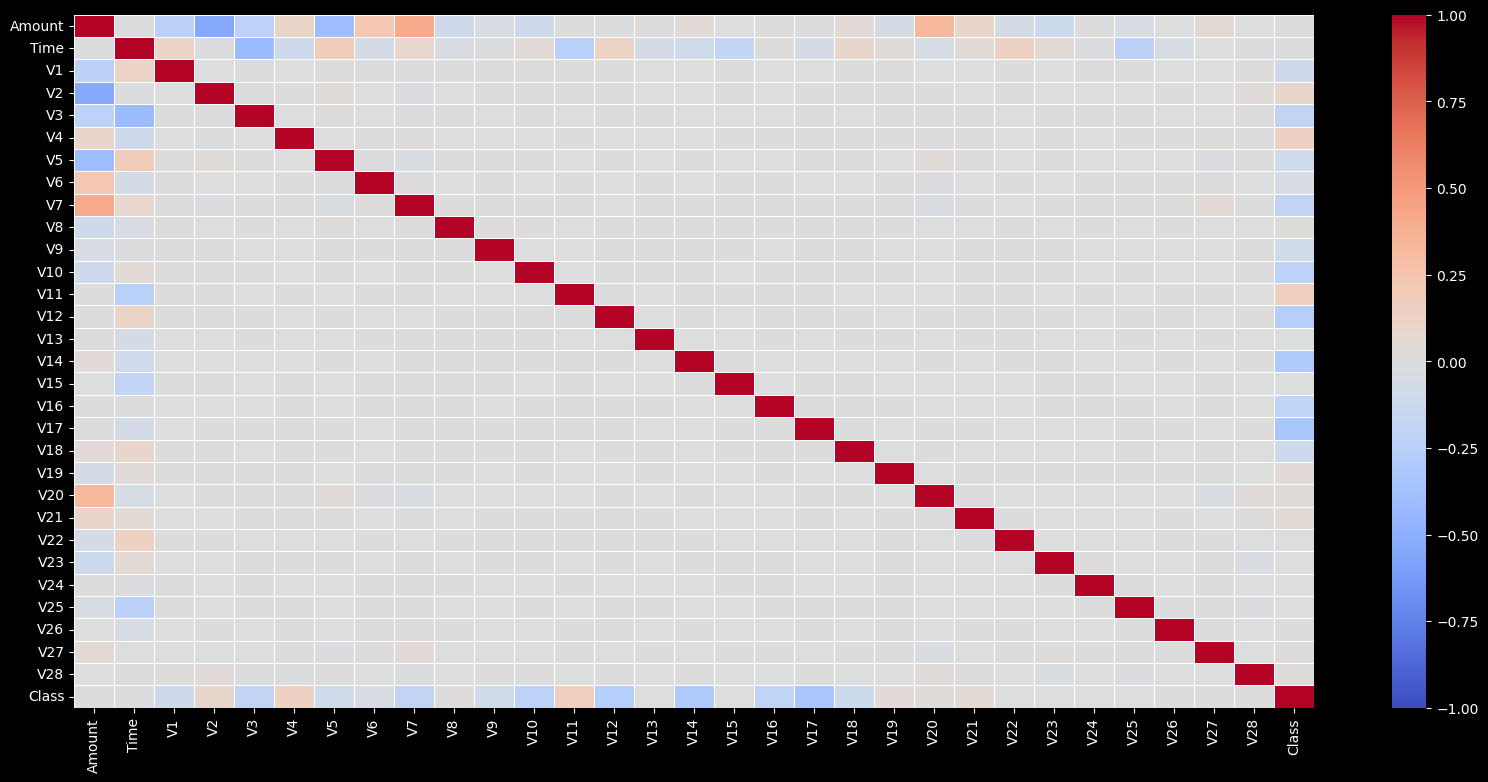

In [22]:
# visualize heatmap to see the correations between features and target feature

numeric_features = ['Amount','Time','V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9',
                    'V10','V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17','V18', 'V19' ,
                    'V20', 'V21', 'V22','V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class']

df_corr = df[numeric_features]

corr = df_corr.corr()

plt.figure(figsize=(20,9))
sns.heatmap(corr,annot=False,linewidths=.5,cmap='coolwarm',vmin=-1,vmax=1,center=0)

plt.show()

# 4. PCA

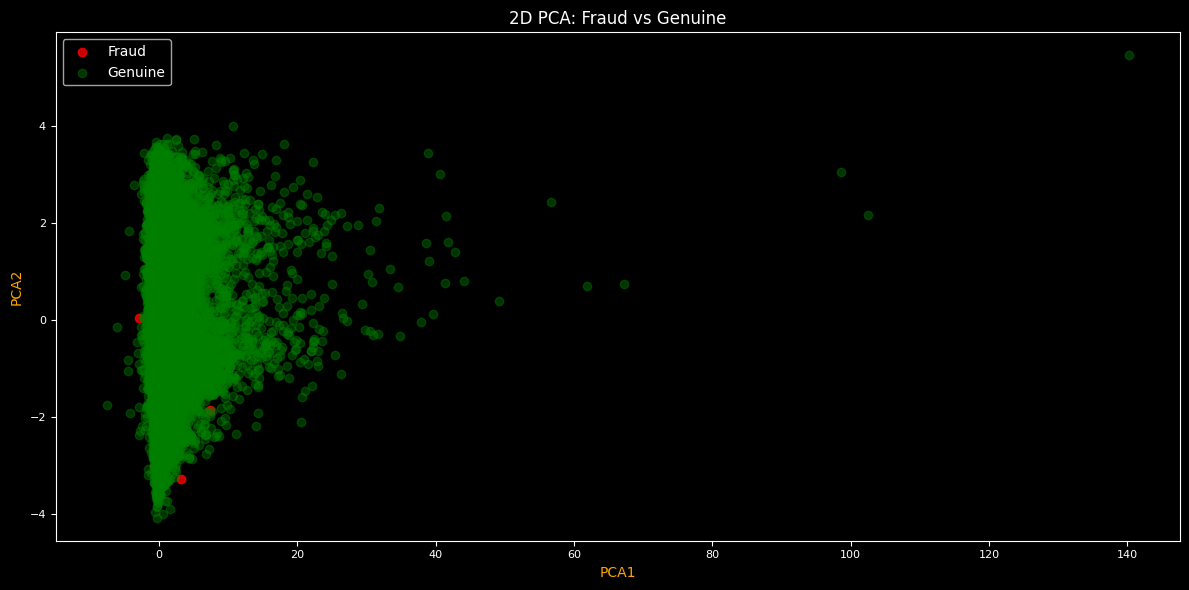

In [23]:
# 2d visaulization to see the variance and if the data is separable

pca_features = ['Amount','Time','V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9',
                    'V10','V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17','V18', 'V19' ,
                    'V20', 'V21', 'V22','V23', 'V24', 'V25', 'V26', 'V27', 'V28']

# prepare x, y features
x = df[pca_features]
y = df['Class']

# scaling before PCA
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# PCA
x_pca = PCA(n_components=2).fit_transform(x_scaled)
pca_df = pd.DataFrame(data=x_pca, columns=['PCA1', 'PCA2'])
pca_df['Class'] = df['Class'].values

# fig specs
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111)

# Split data by class for plotting
fraud = pca_df[pca_df['Class'] == 1]
genuine = pca_df[pca_df['Class'] == 0]

# plot with different concentrations(alphas)
ax.scatter(x=fraud['PCA1'], y=fraud['PCA2'],
           label='Fraud', color='red', alpha=0.8)
ax.scatter(x=genuine['PCA1'], y=genuine['PCA2'],
           label='Genuine', color='green', alpha=0.4)

ax.set_xlabel('PCA1', color='orange')
ax.set_ylabel('PCA2', color='orange')
ax.set_title('2D PCA: Fraud vs Genuine')
ax.tick_params(axis='both', labelsize=8)

plt.legend()
plt.tight_layout()
plt.show()

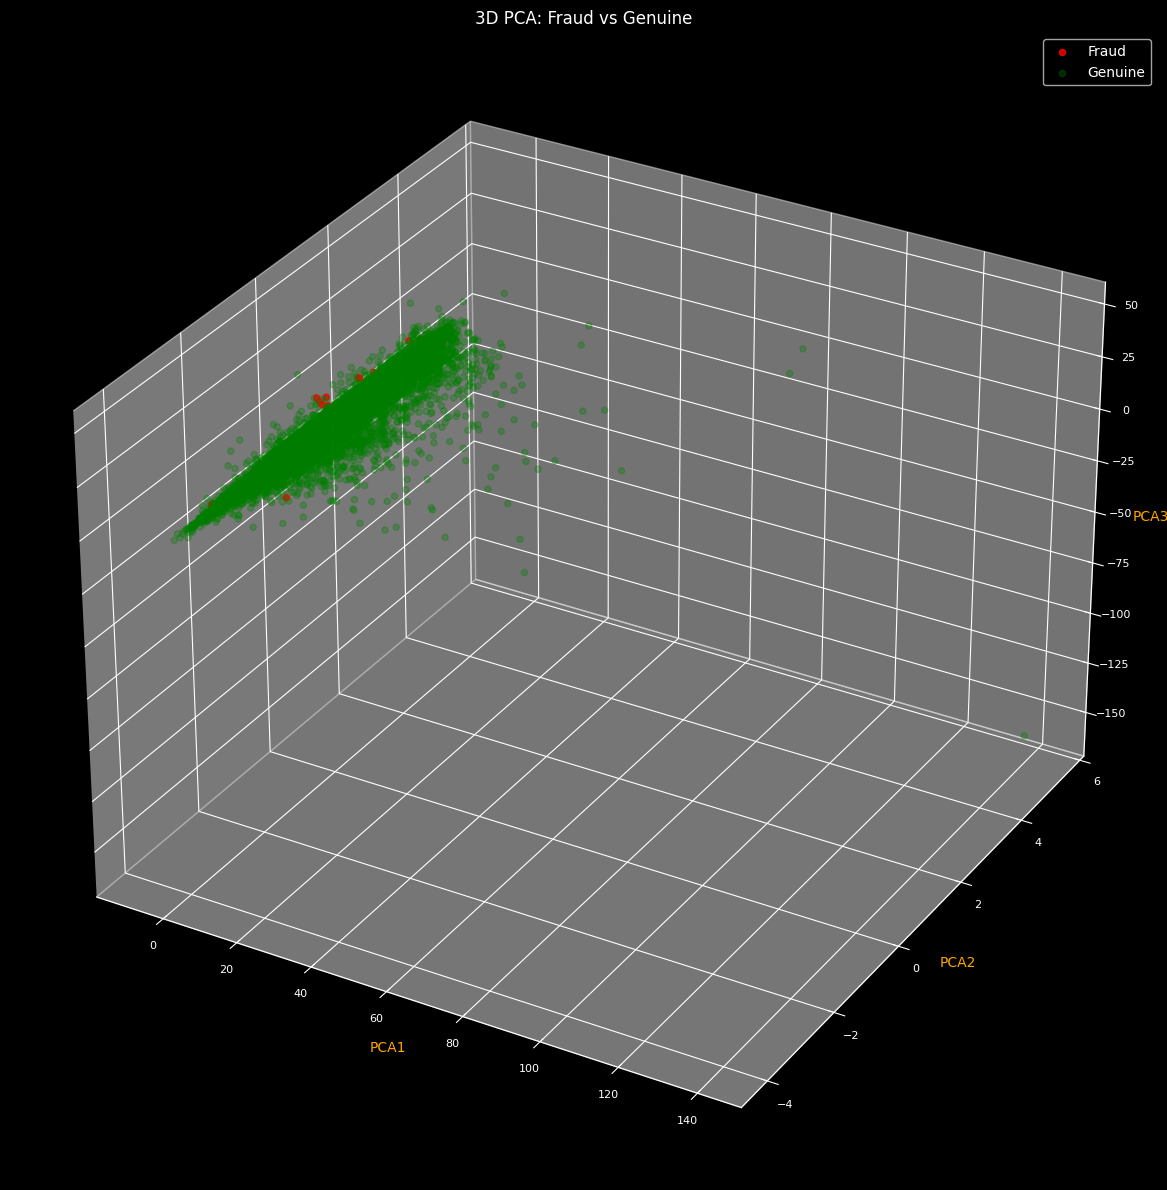

In [24]:
# let's visualize 3D
pca_features = ['Amount','Time','V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9',
                    'V10','V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17','V18', 'V19' ,
                    'V20', 'V21', 'V22','V23', 'V24', 'V25', 'V26', 'V27', 'V28']

#prepare features
x = df[pca_features]
y = df['Class']


# scaling befor PCA
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# PCA
x_pca = PCA(n_components=3).fit_transform(x_scaled)
pca_df = pd.DataFrame(data=x_pca, columns=['PCA1', 'PCA2','PCA3'])
pca_df['Class'] = df['Class'].values

# fig specs
fig = plt.figure(figsize=(20, 12))
ax = fig.add_subplot(111, projection='3d')

# Split data by class for plotting
fraud = pca_df[pca_df['Class'] == 1]
genuine = pca_df[pca_df['Class'] == 0]

# plot with different concentrations(alphas)
ax.scatter(fraud['PCA1'], fraud['PCA2'], fraud['PCA3'], 
           label='Fraud', color='red', alpha=0.8)
ax.scatter(genuine['PCA1'], genuine['PCA2'], genuine['PCA3'], 
           label='Genuine', color='green', alpha=0.3) 

ax.set_xlabel('PCA1', color='orange')
ax.set_ylabel('PCA2', color='orange')
ax.set_zlabel('PCA3', color='orange')
ax.set_title('3D PCA: Fraud vs Genuine')
ax.tick_params(axis='both', labelsize=8)

plt.legend()
plt.tight_layout()
plt.show()

### Observatoin
- The 3D PCA visualization reveals a **dominant linear variance structure**, with both classes distributed along the same principal direction.
- The minority class(Frauds) does not form a **distinct cluster** because it lies under Genuines cloud.

### Thoughts
- **Class separability** is not aligned with the highest variance directions.
- This Requires **nonlinear modeling techniques**.

# Conclusion

- **Log transformation** method for skewed data like Amount feature
- **Imbalanced dataset** requires some techniques to improve modeling **(undersampling, oversampling, ...)**
- Time feature tells some stories about fraud transactions **(Frauds appears more at Night)**